In [1]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("arjunbasandrai/25-indian-bird-species-with-226k-images")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 9.33G/9.33G [07:39<00:00, 21.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4
Contents of base_path (/root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions):
['4']
Contents of path (/root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4):
['training_data', 'training_set']


In [2]:
print(f"Contents of the 'training_set' directory: {os.listdir(os.path.join(path, 'training_set'))}")
print(f"Contents of the 'training_data' directory: {os.listdir(os.path.join(path, 'training_data'))}")

Contents of the 'training_set' directory: ['training_set']
Contents of the 'training_data' directory: ['val', 'train', 'test']



--- Sample Images from training_set (/root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_set) ---
Found 22620 images in /root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_set. Displaying 6 samples:


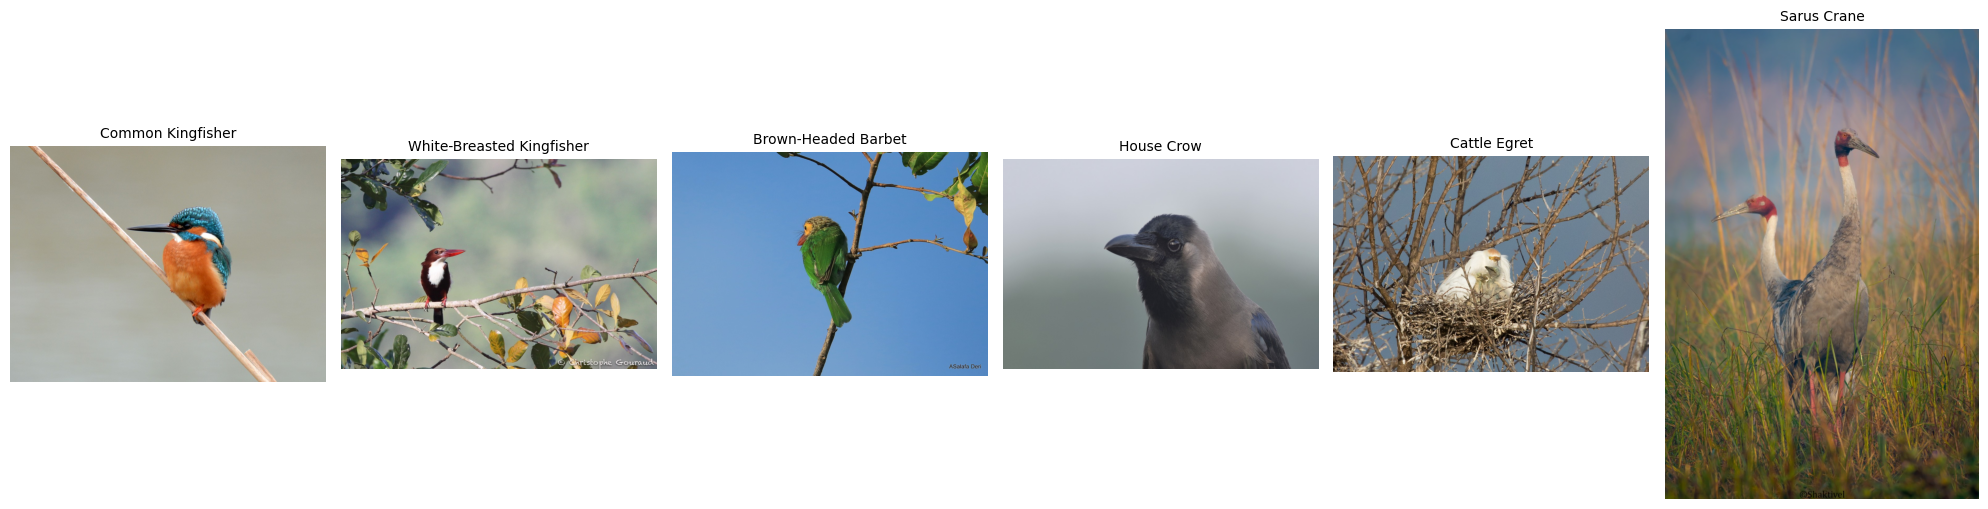


--- Sample Images from training_data (/root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_data) ---
No images found in /root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_data.


In [3]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Extract species name from the directory name
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(label, fontsize=10)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to use the actual dataset folders found in cell IXEO7kTkTmB8
training_set_path = os.path.join(path, 'training_set')
print(f"\n--- Sample Images from training_set ({training_set_path}) ---")
display_sample_images(training_set_path)

training_data_path = os.path.join(path, 'training_data')
print(f"\n--- Sample Images from training_data ({training_data_path}) ---")
display_sample_images(training_data_path)


In [4]:
import os

# Define the actual path containing the bird species folders
# Based on previous results, it is located in training_set/training_set
input_folder = os.path.join(path, 'training_set', 'training_set')
output_folder = '/content/bird_dataset_split'

if not os.path.exists(input_folder):
    # Fallback if the directory structure is not nested
    input_folder = os.path.join(path, 'training_set')

print(f"Preparing to split data from: {input_folder}")

Preparing to split data from: /root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_set/training_set


In [5]:
!pip install split-folders

In [6]:
import splitfolders

# Split the dataset: train=0.8, test=0.2
# seed=42 to ensure reproducibility
# We are splitting into train and val (using val as the test set as requested)
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.8, .2), group_prefix=None, move=False)

print(f"Data split successfully into folder: {output_folder}")

Copying files: 22620 files [00:45, 491.96 files/s]

Data split successfully into folder: /content/bird_dataset_split


In [7]:
# Check the directory structure after splitting
for root, dirs, files in os.walk(output_folder):
    level = root.replace(output_folder, '').count(os.sep)
    indent = ' ' * 4 * (level)
    if level <= 2: # Only print up to species level to avoid long output
        print(f"{indent}{os.path.basename(root)}/")

bird_dataset_split/
    val/
        White-Breasted Kingfisher/
        Rufous Treepie/
        Red-Wattled Lapwing/
        Cattle Egret/
        Coppersmith Barbet/
        Gray Wagtail/
        White Wagtail/
        Indian Pitta/
        Hoopoe/
        Common Kingfisher/
        Forest Wagtail/
        Common Myna/
        Asian Green Bee-Eater/
        Ruddy Shelduck/
        Brown-Headed Barbet/
        Common Rosefinch/
        Jungle Babbler/
        House Crow/
        Northern Lapwing/
        Indian Peacock/
        Sarus Crane/
        Indian Grey Hornbill/
        Common Tailorbird/
        White-Breasted Waterhen/
        Indian Roller/
    train/
        White-Breasted Kingfisher/
        Rufous Treepie/
        Red-Wattled Lapwing/
        Cattle Egret/
        Coppersmith Barbet/
        Gray Wagtail/
        White Wagtail/
        Indian Pitta/
        Hoopoe/
        Common Kingfisher/
        Forest Wagtail/
        Common Myna/
        Asian Green Bee-Eater/
     

In [8]:
import os

def count_files(directory):
    return sum([len(files) for r, d, files in os.walk(directory)])

train_count = count_files(os.path.join(output_folder, 'train'))
test_count = count_files(os.path.join(output_folder, 'val'))
total = train_count + test_count

print(f"New dataset statistics:")
print(f"- Train Set: {train_count} images ({train_count/total*100:.1f}%)")
print(f"- Test Set (val): {test_count} images ({test_count/total*100:.1f}%)")
print(f"- Total: {total} images")

New dataset statistics:
- Train Set: 18090 images (80.0%)
- Test Set (val): 4530 images (20.0%)
- Total: 22620 images


In [9]:
import tensorflow as tf

# Check for GPU
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU device not found. Please enable GPU in Notebook Settings.')
else:
    print(f'Found GPU at: {device_name}')

# List physical devices
physical_devices = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(physical_devices))

Found GPU at: /device:GPU:0
Num GPUs Available:  1


In [10]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 25

# Data Augmentation and Loading
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(output_folder, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(output_folder, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Building Model using GPU strategy
strategy = tf.distribute.OneDeviceStrategy(device="/gpu:0")
with strategy.scope():
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(NUM_CLASSES, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("DenseNet model built and compiled.")

Found 18090 images belonging to 25 classes.
Found 4530 images belonging to 25 classes.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
DenseNet model built and compiled.


In [11]:
EPOCHS = 10

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=EPOCHS
)

Epoch 1/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 811s 1s/step - accuracy: 0.7102 - loss: 1.0332 - val_accuracy: 0.6401 - val_loss: 1.6350
Epoch 2/10
  1/565 ━━━━━━━━━━━━━━━━━━━━ 6:18 672ms/step - accuracy: 0.8438 - loss: 0.6444

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


565/565 ━━━━━━━━━━━━━━━━━━━━ 83s 147ms/step - accuracy: 0.8438 - loss: 0.6444 - val_accuracy: 0.6354 - val_loss: 1.6854
Epoch 3/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 813s 1s/step - accuracy: 0.8335 - loss: 0.6026 - val_accuracy: 0.6970 - val_loss: 1.3156
Epoch 4/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 90s 158ms/step - accuracy: 0.7812 - loss: 0.8098 - val_accuracy: 0.7032 - val_loss: 1.2471
Epoch 5/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 816s 1s/step - accuracy: 0.8642 - loss: 0.4891 - val_accuracy: 0.7883 - val_loss: 0.8250
Epoch 6/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 92s 161ms/step - accuracy: 0.8750 - loss: 0.4830 - val_accuracy: 0.7844 - val_loss: 0.8401
Epoch 7/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 833s 1s/step - accuracy: 0.8887 - loss: 0.4046 - val_accuracy: 0.8351 - val_loss: 0.5931
Epoch 8/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 91s 161ms/step - accuracy: 0.9688 - loss: 0.1179 - val_accuracy: 0.8342 - val_loss: 0.6022
Epoch 9/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 861s 2s/step - accuracy: 0.8922 - loss: 0.3816 - val_accurac

In [12]:
final_loss, final_accuracy = model.evaluate(val_generator)
print(f"Final Validation Accuracy: {final_accuracy*100:.2f}%")
print(f"Final Validation Loss: {final_loss:.4f}")

142/142 ━━━━━━━━━━━━━━━━━━━━ 93s 651ms/step - accuracy: 0.8715 - loss: 0.5121
Final Validation Accuracy: 87.15%
Final Validation Loss: 0.5121


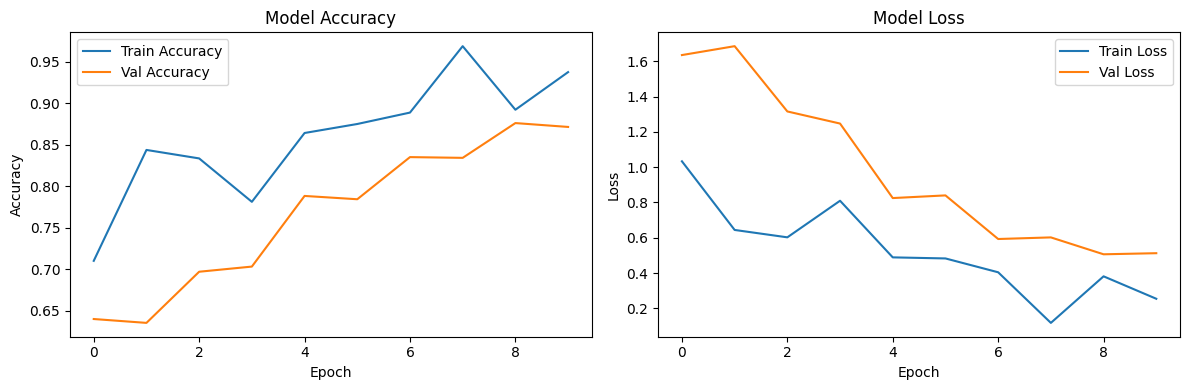

In [13]:
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()